# 02 — Explore the comprehensive comparison

Pulls every results JSON in `outputs/logs/` and renders the headline numbers,
per-network heatmap, FC-translation correlations, subject-level CV gap, and
null z-scores — all inline.

Re-run after `pipeline/05_evaluate.py` (and friends) to get a fresh view.

The sections are ordered for a reviewer: region-level performance first (the headline framing), then the comparative configs, per-network detail, nulls, bootstrap stability, and per-parcel trust.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore', category=DeprecationWarning, module='homer\\..*')

import json
import numpy as np
import pandas as pd
from homer.viz.reports import build_comparison_table, render_summary_md
from homer.viz.notebook import plot_per_network_heatmap, plot_comparison_bars

ROOT = Path.cwd().parent
LOG  = ROOT / 'outputs' / 'logs'
CMP  = ROOT / 'outputs' / 'comparison'

## 1. Build the comparison table

One function call: pulls every JSON in `outputs/logs/` and returns a wide DataFrame, a long DataFrame, the null z-score dict, and the bootstrap dict.

In [2]:
wide_df, long_df, null_z, bootstrap = build_comparison_table(LOG)
print(f'{len(wide_df)} configs × {wide_df.shape[1]} columns in wide table')
print(f'{len(long_df)} (config, network) cells in long table')
wide_df.head()

16 configs × 24 columns in wide table
156 (config, network) cells in long table


,config,label,notes,anchor_top1,anchor_top5,anchor_pair,anchor_hemi,anchor_mean_rank,anchor_mean_xyz_dist,n_anchors_total,...,full_in_neighborhood,full_mass_on_correct,fc_translation_r,fc_translation_within_net,fc_translation_cross_net,fc_translation_n_kept,subject_cv_train_r,subject_cv_test_r,subject_cv_test_r_std,subject_cv_gap
0,baseline_fc_only,baseline (FC only),,0.785714,1.0,0.785714,1.000000,1.261905,0.021166,42,...,NaN,NaN,0.364281,0.447025,0.199168,1443,0.359697,0.318918,0.005514,-0.040779
1,fc_plus_xyz_gw,FC + xyz GW,,0.809524,1.0,0.809524,1.000000,1.238095,0.019977,42,...,NaN,NaN,0.365184,0.448727,0.202508,1499,NaN,NaN,NaN,NaN
2,fc_plus_network_mask,FC + network mask,,0.809524,1.0,0.809524,1.000000,1.238095,0.019977,42,...,NaN,NaN,0.379543,0.492637,0.169893,835,NaN,NaN,NaN,NaN
3,fc_plus_SC,FC + SC (production),production,0.809524,1.0,0.809524,1.000000,1.238095,0.019977,42,...,0.071429,0.023917,0.361017,0.443506,0.198248,1379,0.356657,0.317814,0.006123,-0.038843
4,fc_plus_gene_GW,FC + gene GW,,0.761905,NaN,0.809524,0.952381,NaN,NaN,42,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN


## 2. Region-level evaluation

The parcel-level metrics above ask "is the right human *parcel* in the top-K?". This section asks the region-level analogue: "given a mouse region, which *human region* does π predict from a candidate set?" — which is the right framing for a downstream user who works at region granularity. See `docs/results.md §5.10` for the methodology and full numbers.

We load results for two candidate sets:

- **Beauchamp-22** (21 evaluable) — the 22 hand-curated human regions from `pipeline/05f_beauchamp_validation.py`. Chance top-1 ≈ 5%.
- **JuBrain ∪ extras** (~151 candidates) — JuBrain-184 cytoarchitectonic atlas plus 7 subcortical Beauchamp targets that JuBrain lacks. Chance top-1 ≈ 0.7%.

In [15]:
import json, pandas as pd
from pathlib import Path

LOG = Path('../outputs/logs')

def load_eval(name):
    p = LOG / name
    if not p.exists():
        print(f"⚠ {name} missing — run pipeline/05j_region_level_eval.py")
        return None
    return json.loads(p.read_text())

res_b22  = load_eval('region_level_eval.json')              # Beauchamp-22
res_jub  = load_eval('region_level_eval_jubrain.json')      # JuBrain ∪ extras

# Per-pair table for Beauchamp-22 candidate set
def pair_df(res, label):
    if res is None: return None
    rows = []
    for p in res['per_pair']:
        rows.append({
            'pair': p['pair'],
            'n_m': p['n_mouse_parcels'],
            'n_h': p['n_human_parcels'],
            f'rank({label})': p['rank'],
            f'mass({label})': p['score_true'],
            f'fold({label})': p['fold_enrichment'],
            f'q-top1({label})': p['qualified_top_k_hits'].get('1', False),
            f'q-top3({label})': p['qualified_top_k_hits'].get('3', False),
            f'q-top5({label})': p['qualified_top_k_hits'].get('5', False),
            f'coverage({label})': p['total_mass_in_candidates'],
            'anchor?': p['is_anchor_overlapping'],
        })
    return pd.DataFrame(rows)

df_b22 = pair_df(res_b22, 'B22')
df_b22.style.format({
    'mass(B22)': '{:.3f}', 'fold(B22)': '{:.1f}x', 'coverage(B22)': '{:.0%}',
})

,pair,n_m,n_h,rank(B22),mass(B22),fold(B22),q-top1(B22),q-top3(B22),q-top5(B22),coverage(B22),anchor?
0,Piriform area -> piriform cortex,47,13,1,0.000,0.0x,False,False,False,0%,True
1,Subiculum -> subiculum,29,8,2,0.000,0.0x,False,False,False,3%,False
2,Field CA1 -> CA1 field,15,6,3,0.000,0.0x,False,False,False,0%,False
3,Field CA3 -> CA3 field,26,4,4,0.000,0.0x,False,False,False,0%,False
4,Dentate gyrus -> dentate gyrus,22,4,3,0.000,0.0x,False,False,False,5%,False
5,Anterior cingulate area -> cingulate gyrus,23,24,1,0.130,11.4x,True,True,True,17%,True
6,Primary auditory area -> Heschl's gyrus,9,18,1,0.222,25.9x,True,True,True,22%,True
7,Primary motor area -> precentral gyrus,53,45,1,0.000,0.0x,False,False,False,0%,True
8,Primary somatosensory area -> postcentral gyrus,155,39,2,0.200,10.7x,False,True,True,28%,True
9,Visual areas -> cuneus,54,36,1,0.074,4.3x,True,True,True,7%,True


### 2.1 Aggregate comparison across candidate sets

The aggregate numbers tell the headline story. For supervised pairs the model identifies the right human region with mean rank well inside the top 10% of the candidate set, with fold enrichment in the 15-16× range under both candidate sets. The novel hippocampal pairs (no Garin anchor) correctly score 0 under the *qualified* metric (which requires both rank ≤ k and fold ≥ 1).

Note the candidate-set mass coverage rises from ~20% (Beauchamp-22) to ~67% (JuBrain) — the JuBrain set actually captures where the model puts its mass, so the rank-based metrics there are more meaningful.

In [16]:
# Aggregate side-by-side
rows = []
for label, res in [('Beauchamp-22', res_b22), ('JuBrain ∪ extras', res_jub)]:
    if res is None: continue
    agg = res['aggregate']
    rows.append({
        'candidate_set': label,
        'n_candidates': res['n_candidates'],
        'top-1 (rank)':       agg['top_k']['1'],
        'top-3 (rank)':       agg['top_k']['3'],
        'top-5 (rank)':       agg['top_k']['5'],
        'q-top-1':            agg['qualified_top_k']['1'],
        'q-top-3':            agg['qualified_top_k']['3'],
        'q-top-5':            agg['qualified_top_k']['5'],
        'mean rank':          agg['mean_rank'],
        'mean fold':          agg['mean_fold_enrichment'],
        'coverage':           agg['mean_total_mass_in_candidates'],
    })
agg_df = pd.DataFrame(rows)
agg_df.style.format({
    'top-1 (rank)': '{:.1%}', 'top-3 (rank)': '{:.1%}', 'top-5 (rank)': '{:.1%}',
    'q-top-1': '{:.1%}', 'q-top-3': '{:.1%}', 'q-top-5': '{:.1%}',
    'mean rank': '{:.2f}', 'mean fold': '{:.1f}x', 'coverage': '{:.1%}',
})

,candidate_set,n_candidates,top-1 (rank),top-3 (rank),top-5 (rank),q-top-1,q-top-3,q-top-5,mean rank,mean fold,coverage
0,Beauchamp-22,21,46.5%,87.8%,90.4%,33.9%,63.5%,63.5%,2.01,14.4x,20.1%
1,JuBrain ∪ extras,151,25.4%,32.8%,55.2%,25.4%,32.8%,55.2%,10.66,14.5x,67.1%


### 2.2 Fold enrichment per pair (Beauchamp-22)

Fold enrichment is `mass on H_true / (|H_true|/n_h)` — how much the model concentrates mass on the canonical target relative to a uniform π. > 1 = enriched, < 1 = depleted. Hippocampal subfields (novel pairs, no anchor) show fold ≈ 0 — correctly reflecting that the model has no supervision in those regions.

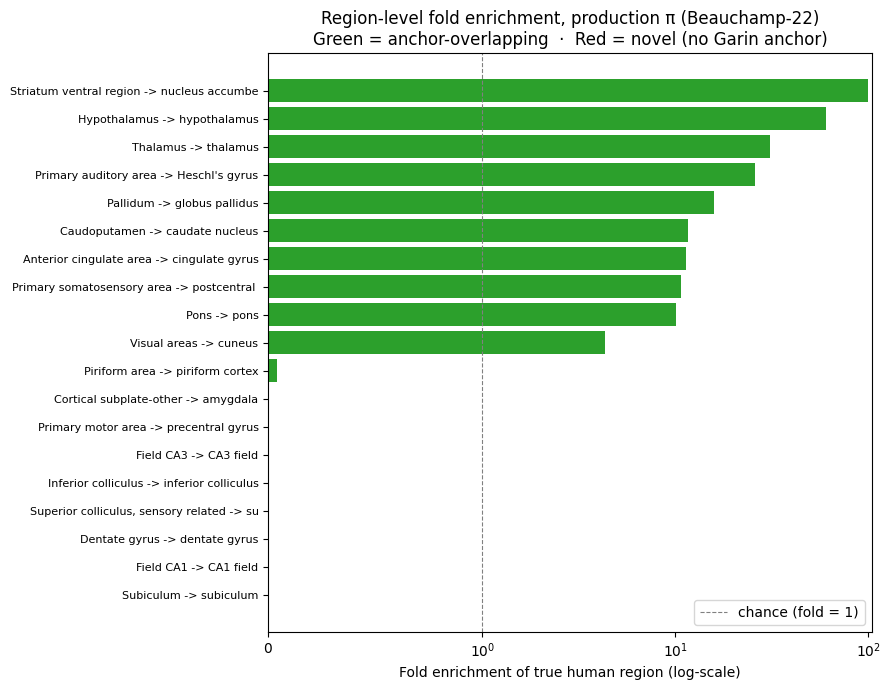

In [17]:
import matplotlib.pyplot as plt

df = df_b22.sort_values('fold(B22)', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca02c' if x else '#d62728' for x in df['anchor?']]
ax.barh(range(len(df)), df['fold(B22)'], color=colors)
ax.set_yticks(range(len(df)))
ax.set_yticklabels([p[:42] for p in df['pair']], fontsize=8)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8, label='chance (fold = 1)')
ax.set_xlabel('Fold enrichment of true human region (log-scale)')
ax.set_title('Region-level fold enrichment, production π (Beauchamp-22)\nGreen = anchor-overlapping  ·  Red = novel (no Garin anchor)')
ax.set_xscale('symlog', linthresh=1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2.3 Null calibration

Two nulls per candidate set:

- **Column-permuted**: shuffle pi_M column order. Preserves total mass, destroys location. Tests if mass on the target region beats what mass of that magnitude would give by chance.
- **Source-permuted**: score H_true against another mouse region's pi_M. The stronger test — tests if mass on H_true is *specific* to its matching mouse region M, not a generic model bias.

The model passes both at top-1 with z ≥ +4σ under both candidate sets, including the strict source-permuted null.

In [18]:
null_rows = []
for label, res in [('Beauchamp-22', res_b22), ('JuBrain ∪ extras', res_jub)]:
    if res is None: continue
    agg = res['aggregate']
    for null_name, key in [('column-perm', 'null_column_permuted'),
                            ('source-perm', 'null_source_permuted')]:
        n = res.get(key)
        if n is None: continue
        for k in (1, 3, 5):
            real = agg['top_k'][str(k)]
            mu, sd = n['null_topk_mean'][str(k)], n['null_topk_std'][str(k)]
            null_rows.append({
                'candidate_set': label, 'null': null_name, 'k': k,
                'real': real, 'null_mean': mu, 'null_std': sd,
                'z': (real - mu) / max(sd, 1e-9),
            })
null_df = pd.DataFrame(null_rows)
null_df.style.format({'real': '{:.1%}', 'null_mean': '{:.1%}',
                       'null_std': '{:.1%}', 'z': '{:+.1f}'})

,candidate_set,null,k,real,null_mean,null_std,z
0,Beauchamp-22,column-perm,1,46.5%,8.4%,9.0%,+4.2
1,Beauchamp-22,column-perm,3,87.8%,24.8%,13.4%,+4.7
2,Beauchamp-22,column-perm,5,90.4%,38.0%,12.5%,+4.2
3,Beauchamp-22,source-perm,1,46.5%,11.2%,8.0%,+4.4
4,Beauchamp-22,source-perm,3,87.8%,52.1%,11.2%,+3.2
5,Beauchamp-22,source-perm,5,90.4%,66.6%,11.1%,+2.1
6,JuBrain ∪ extras,column-perm,1,25.4%,1.1%,3.4%,+7.1
7,JuBrain ∪ extras,column-perm,3,32.8%,3.8%,6.7%,+4.3
8,JuBrain ∪ extras,column-perm,5,55.2%,7.9%,8.7%,+5.5
9,JuBrain ∪ extras,source-perm,1,25.4%,2.5%,5.0%,+4.6


## 3. Headline metrics across all configs

In [3]:
headline_cols = [
    'label', 'anchor_top1', 'anchor_top5', 'anchor_pair', 'anchor_hemi',
    'anchor_mean_rank', 'anchor_mean_xyz_dist',
    'fc_translation_r', 'subject_cv_test_r', 'notes',
]
view = wide_df[headline_cols].copy()
# Format percentages for readability
for c in ('anchor_top1', 'anchor_top5', 'anchor_pair', 'anchor_hemi'):
    view[c] = view[c].apply(lambda x: f'{x:.0%}' if np.isfinite(x) else '—')
view

,label,anchor_top1,anchor_top5,anchor_pair,anchor_hemi,anchor_mean_rank,anchor_mean_xyz_dist,fc_translation_r,subject_cv_test_r,notes
0,baseline (FC only),79%,100%,79%,100%,1.261905,0.021166,0.364281,0.318918,
1,FC + xyz GW,81%,100%,81%,100%,1.238095,0.019977,0.365184,NaN,
2,FC + network mask,81%,100%,81%,100%,1.238095,0.019977,0.379543,NaN,
3,FC + SC (production),81%,100%,81%,100%,1.238095,0.019977,0.361017,0.317814,production
4,FC + gene GW,76%,—,81%,95%,NaN,NaN,NaN,NaN,
5,FC + M_gene,60%,—,64%,93%,NaN,NaN,NaN,NaN,
6,FC + SC + M_gene,62%,—,69%,90%,NaN,NaN,NaN,NaN,
7,all modalities (FC+xyz+SC+gene),64%,—,71%,90%,NaN,NaN,NaN,NaN,
8,FC + selective M_gene,60%,—,64%,93%,NaN,NaN,NaN,NaN,
9,FC + SC + selective M_gene,62%,—,69%,90%,NaN,NaN,NaN,NaN,


## 4. Full-space recovery — the honest per-voxel metric

The headline `anchor_top1` above is *restricted* to held-out anchor candidates. The
table below uses the global argmax over all 2094 human nodes. **Big drop expected** —
the model's full-space argmax usually lands on a non-anchor grid node *near* the correct
anchor, not the anchor itself.

In [4]:
fs_cols = ['label', 'full_top1', 'full_top5', 'full_mean_rank',
           'full_argmax_is_anchor', 'full_in_neighborhood', 'full_mass_on_correct',
           'notes']
fs_view = wide_df.dropna(subset=['full_top1'])[fs_cols].copy()
for c in ('full_top1', 'full_top5', 'full_argmax_is_anchor', 'full_in_neighborhood'):
    fs_view[c] = fs_view[c].apply(lambda x: f'{x:.0%}' if np.isfinite(x) else '—')
for c in ('full_mean_rank',):
    fs_view[c] = fs_view[c].apply(lambda x: f'{x:.0f}' if np.isfinite(x) else '—')
for c in ('full_mass_on_correct',):
    fs_view[c] = fs_view[c].apply(lambda x: f'{x:.3f}' if np.isfinite(x) else '—')
fs_view

,label,full_top1,full_top5,full_mean_rank,full_argmax_is_anchor,full_in_neighborhood,full_mass_on_correct,notes
3,FC + SC (production),2%,12%,206,5%,7%,0.024,production


## 5. Per-network heatmap

The variance across networks is the story — most configs land 100% on the
easy networks (auditory, frontoparietal, frontal_dmn, ...) and 25-50% on
the hard ones (visual, brainstem, sensorimotor, salience, subcortical).

In [6]:
plot_per_network_heatmap(long_df)

## 6. Null calibration

How does the production model do vs random π and permuted-anchor null distributions?

In [7]:
null_table = pd.DataFrame([
    {
        'null_kind':   k,
        'n_trials':    v['n_trials'],
        'real_top1':   f'{v["real_top1"]:.0%}',
        'null_mean':   f'{v["null_mean"]:.0%}',
        'null_std':    f'{v["null_std"]:.0%}',
        'z_score':     f'{v["z_score"]:+.1f}',
    }
    for k, v in null_z.items()
])
null_table

,null_kind,n_trials,real_top1,null_mean,null_std,z_score
0,random_pi,50,81%,28%,7%,+7.5
1,permuted_anchors,5,81%,31%,3%,+17.8


## 7. Subject-level cross-validation (item D)

For the two configs we ran subject CV on, what's the train/test gap?

In [8]:
subj_path = LOG / 'subject_cv.json'
if subj_path.exists():
    sv = json.loads(subj_path.read_text())
    rows = []
    for cfg_key, folds in sv.items():
        fr = list(folds.values())
        rows.append({
            'config': cfg_key.split('__')[0],
            'n_folds':    len(fr),
            'train_r':    f'{np.mean([f["train_r_overall"] for f in fr]):.3f} ± '
                          f'{np.std([f["train_r_overall"] for f in fr]):.3f}',
            'test_r':     f'{np.mean([f["test_r_overall"] for f in fr]):.3f} ± '
                          f'{np.std([f["test_r_overall"] for f in fr]):.3f}',
            'gap':        f'{np.mean([f["test_minus_train"] for f in fr]):+.3f} ± '
                          f'{np.std([f["test_minus_train"] for f in fr]):.3f}',
        })
    pd.DataFrame(rows)
else:
    print('No subject_cv.json yet — run experiments/D_subject_cv/subject_cv.py first.')
    pd.DataFrame()

## 8. Bootstrap stability

From 40 subject-level bootstrap iterations of the production model.

In [9]:
# Note: post-fix bootstrap files are per-config (fc_plus_SC, fc_only).
# build_comparison_table prefers the SC one. Show both shapes for completeness.
if not bootstrap:
    print('No bootstrap_summary file yet — run pipeline/06_bootstrap.py.')
else:
    keys_old = ['n_iterations', 'mean_stability', 'median_stability',
                'frac_stable_above_0.8', 'frac_stable_above_0.5']
    keys_new = ['config', 'n_iterations',
                'argmax_row_stability_mean', 'argmax_row_stability_median',
                'argmax_row_frac_above_0.8', 'argmax_row_frac_above_0.5',
                'argmax_row_frac_perfect',
                'cell_stability_mean', 'cell_frac_stable_above_0.8']
    keys = keys_new if 'argmax_row_stability_mean' in bootstrap else keys_old
    for k in keys:
        v = bootstrap.get(k)
        if v is None: continue
        if isinstance(v, float) and 0 <= v <= 1 and ('frac' in k or 'stability' in k):
            print(f'  {k:35s} {v:.1%}')
        elif isinstance(v, float):
            print(f'  {k:35s} {v:.4f}')
        else:
            print(f'  {k:35s} {v}')

  config                              fc_plus_SC
  n_iterations                        40
  argmax_row_stability_mean           97.8%
  argmax_row_stability_median         100.0%
  argmax_row_frac_above_0.8           95.0%
  argmax_row_frac_above_0.5           99.4%
  argmax_row_frac_perfect             88.4%
  cell_stability_mean                 100.0%
  cell_frac_stable_above_0.8          100.0%


## 9. Trust map — where to (and not to) trust the model

Per-parcel trust signal computed in `pipeline/05g_compute_trust.py`. We
expose two views:

- **Regional empirical trust** — per-region top-1 against Beauchamp 2022.
  This is the honest signal: emerald = top-1 ≥15% in this region (Thalamus,
  Auditory, Somatosensory), amber = 3-15%, red = <3%, grey = parcel not in
  any of our 19 evaluable Beauchamp regions.
- **Model-confidence trust** — composite of bootstrap stability +
  argmax mass concentration + FC similarity to nearest anchor. Less
  informative (88% of parcels have perfect bootstrap & concentration,
  so it mostly reflects FC similarity).

The regional view is what you should use to decide whether to trust a
specific prediction.


In [12]:
import numpy as np
from homer.data import load_cached
from homer.viz.notebook import plot_brain_3d

M, _ = load_cached('mouse', cache_dir='../outputs/anndata')
ts = np.load('../outputs/coupling/trust_score_fc_plus_SC.npz')

# Show the regional-tier 3D map
fig = plot_brain_3d(
    M,
    color_by='trust_tier',
    trust_tier=ts['regional_tier'],
    title='Mouse parcels — regional trust tier (production π, fc_plus_SC)',
)
fig.show()


**Reading the colors.** Emerald regions are reliable (Thalamus,
Auditory cortex, Somatosensory cortex — all >15% Beauchamp top-1). Amber
regions are usable as priors with care (Caudoputamen, Cingulate,
Hypothalamus, Visual, etc.). Red regions are where the model fails
(midbrain colliculi, hippocampus without supplementary anchors, motor with
broad anchor only). Grey parcels are not in any validated Beauchamp region
— absence of evidence, not evidence of absence.

In [13]:
# Compare to the augmented π (with M1 + hippocampal supplementary anchors)
import os
aug_path = '../outputs/coupling/trust_score_fc_plus_SC_with_M1_hippo.npz'
if os.path.exists(aug_path):
    ts_aug = np.load(aug_path)
    fig_aug = plot_brain_3d(
        M,
        color_by='trust_tier',
        trust_tier=ts_aug['regional_tier'],
        title='Mouse parcels — regional trust tier (AUGMENTED: + M1 + hippocampal anchors)',
    )
    fig_aug.show()

    # Diff — how many parcels moved from low → medium?
    before = ts['regional_tier']; after = ts_aug['regional_tier']
    upgrades = ((before == 'low') & (after == 'medium')).sum()
    downgrades = ((before == 'medium') & (after == 'low')).sum()
    print(f'Tier upgrades (low → medium): {upgrades} parcels')
    print(f'Tier downgrades (medium → low): {downgrades} parcels')
else:
    print(f'No augmented trust file at {aug_path} — run pipeline/05g_compute_trust.py --pi-file pi_fc_plus_SC_with_M1_hippo.npy')


Tier upgrades (low → medium): 130 parcels
Tier downgrades (medium → low): 0 parcels


## 10. Per-region accuracy table

The empirical Beauchamp top-1 per region — directly readable as "how often
does the model land in the right region for parcels in this Beauchamp
group?". This drives the trust tier above.

In [14]:
import pandas as pd, json
beau = json.loads(open('../outputs/logs/beauchamp_validation.json').read())
rows = []
for pair, r in beau.items():
    if pair == '__aggregate__' or 'skip_reason' in r: continue
    rows.append({
        'pair': pair[:60],
        'n_mouse': r['n_mouse_parcels'],
        'n_human': r['n_human_parcels'],
        'top1':  r['top1'],
        'top5':  r['top5'],
        'top10': r['top10'],
        'mean_xyz_dist_mm': r['mean_xyz_dist_mm'],
        'is_anchor': r['is_anchor_overlapping'],
    })
df = pd.DataFrame(rows).sort_values('top1', ascending=False)
df.style.format({'top1': '{:.0%}', 'top5': '{:.0%}', 'top10': '{:.0%}',
                  'mean_xyz_dist_mm': '{:.1f}'})\
    .background_gradient(subset=['top1'], cmap='RdYlGn', vmin=0, vmax=0.4)


,pair,n_mouse,n_human,top1,top5,top10,mean_xyz_dist_mm,is_anchor
17,Hypothalamus -> hypothalamus,52,4,100%,100%,100%,6.8,True
18,Thalamus -> thalamus,110,22,34%,48%,55%,24.5,True
5,Anterior cingulate area -> cingulate gyrus,23,24,30%,35%,35%,34.8,True
9,Visual areas -> cuneus,54,36,17%,17%,17%,65.2,True
11,Striatum ventral region -> nucleus accumbens,26,2,15%,35%,50%,20.4,True
10,Pallidum -> globus pallidus,44,6,5%,7%,16%,20.4,True
0,Piriform area -> piriform cortex,47,13,4%,13%,26%,46.5,True
16,Pons -> pons,69,6,3%,3%,3%,52.6,True
8,Primary somatosensory area -> postcentral gyrus,155,39,2%,47%,51%,47.0,True
4,Dentate gyrus -> dentate gyrus,22,4,0%,0%,0%,53.2,False
